In [1]:
!pip install mtcnn opencv-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 22.3 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.8 MB/s eta 0:00:00


In [2]:
import os
import shutil

# Base directory for our processed images
BASE_DIR = '/kaggle/working/dataset'
splits = ['train', 'val', 'test']
classes = ['real', 'fake']

# Clean up previous runs if necessary
if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)

# Create folder structure
for split in splits:
    for cls in classes:
        os.makedirs(os.path.join(BASE_DIR, split, cls), exist_ok=True)
        
print("Directory structure created at /kaggle/working/dataset/")

Directory structure created at /kaggle/working/dataset/


In [4]:
import cv2
import glob
from mtcnn import MTCNN
import numpy as np
from tqdm import tqdm

detector = MTCNN()

def extract_faces_from_video(video_path, output_dir, num_frames=10):
    """Extracts faces from evenly spaced frames in a video, with crash protection."""
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames < num_frames:
        cap.release()
        return

    # Calculate exactly which frames to pull
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    
    video_id = os.path.basename(video_path).split('.')[0]
    count = 0
    
    for i in range(total_frames):
        ret, frame = cap.read()
        if not ret:
            break
            
        if i in frame_indices:
            # Convert BGR (OpenCV format) to RGB (MTCNN format)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            # --- THE FIX: Wrap the detector in a try/except block ---
            try:
                results = detector.detect_faces(frame_rgb)
            except ValueError:
                # This catches the empty Conv2D tensor crash from MTCNN
                results = []
            except Exception as e:
                # Catch any other unexpected detector errors
                results = []
            # --------------------------------------------------------
            
            if results:
                # Get the bounding box of the most prominent face
                bounding_box = results[0]['box']
                x, y, width, height = bounding_box
                
                # Add a 15% margin to capture jawline and hair
                margin_x, margin_y = int(width * 0.15), int(height * 0.15)
                x1 = max(0, x - margin_x)
                y1 = max(0, y - margin_y)
                x2 = min(frame.shape[1], x + width + margin_x)
                y2 = min(frame.shape[0], y + height + margin_y)
                
                # Ensure the crop coordinates don't go outside the image boundaries
                if x1 < 0 or y1 < 0 or x2 > frame.shape[1] or y2 > frame.shape[0]:
                    continue
                
                face_crop = frame[y1:y2, x1:x2]
                
                # Resize to target EfficientNetB3 size and save
                try:
                    # Make sure you are using 300x300 for the B3 model!
                    face_crop = cv2.resize(face_crop, (300, 300))
                    save_path = os.path.join(output_dir, f"{video_id}_frame_{count}.jpg")
                    cv2.imwrite(save_path, face_crop)
                    count += 1
                except Exception as e:
                    pass # Ignore poorly cropped frames
                    
    cap.release()

# --- EXECUTION ---
# UPDATE THESE PATHS to point to your mounted Kaggle input dataset
REAL_VIDEOS_PATH = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/Deepfakes/*.mp4'
FAKE_VIDEOS_PATH = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/original/*.mp4'

real_videos = glob.glob(REAL_VIDEOS_PATH)[:500] # Limiting to 500 for time/space limits
fake_videos = glob.glob(FAKE_VIDEOS_PATH)[:500]

print("Extracting Real Faces...")
for vid in tqdm(real_videos):
    # For a real pipeline, you would split these into train/val folders
    extract_faces_from_video(vid, os.path.join(BASE_DIR, 'train', 'real'))

print("Extracting Fake Faces...")
for vid in tqdm(fake_videos):
    extract_faces_from_video(vid, os.path.join(BASE_DIR, 'train', 'fake'))

Extracting Real Faces...


100%|██████████| 500/500 [1:02:38<00:00,  7.52s/it]


Extracting Fake Faces...


100%|██████████| 500/500 [1:00:02<00:00,  7.20s/it]


In [5]:
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision, callbacks

# Enable Mixed Precision to double speed and prevent T4 Out-Of-Memory errors
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

# Load Data (Assuming you split your extractions into train/val previously)
# If you only extracted to train above, use validation_split here:
train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'train'),
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(BASE_DIR, 'train'),
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 9980 files belonging to 2 classes.
Using 7984 files for training.
Found 9980 files belonging to 2 classes.
Using 1996 files for validation.


In [6]:
# Build EfficientNetB0 Model
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224, 224, 3), include_top=False, weights='imagenet'
)
base_model.trainable = False 

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

model = models.Model(base_model.input, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

# Define Callbacks
callbacks_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2),
    callbacks.ModelCheckpoint('/kaggle/working/best_model.h5', save_best_only=True)
]

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_list,
    verbose=1
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20


I0000 00:00:1780182668.400212     138 service.cc:152] XLA service 0x7a0e1405dc20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780182668.400255     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780182668.400260     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780182670.971967     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1780182701.480087     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - accuracy: 0.5587 - auc: 0.5764 - loss: 0.8205

250/250 ━━━━━━━━━━━━━━━━━━━━ 157s 414ms/step - accuracy: 0.6105 - auc: 0.6468 - loss: 0.7271 - val_accuracy: 0.7410 - val_auc: 0.8173 - val_loss: 0.5682 - learning_rate: 0.0010
Epoch 2/20
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7053 - auc: 0.7668 - loss: 0.5869

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7144 - auc: 0.7838 - loss: 0.5665 - val_accuracy: 0.7751 - val_auc: 0.8614 - val_loss: 0.4856 - learning_rate: 0.0010
Epoch 3/20
248/250 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7332 - auc: 0.8112 - loss: 0.5331

...

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7772 - auc: 0.8598 - loss: 0.4677 - val_accuracy: 0.8442 - val_auc: 0.9131 - val_loss: 0.3957 - learning_rate: 2.0000e-04
Epoch 12/20
249/250 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7752 - auc: 0.8602 - loss: 0.4691

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7806 - auc: 0.8647 - loss: 0.4598 - val_accuracy: 0.8472 - val_auc: 0.9164 - val_loss: 0.3917 - learning_rate: 2.0000e-04
Epoch 13/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7727 - auc: 0.8596 - loss: 0.4669 - val_accuracy: 0.8432 - val_auc: 0.9157 - val_loss: 0.3930 - learning_rate: 2.0000e-04
Epoch 14/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7836 - auc: 0.8688 - loss: 0.4519 - val_accuracy: 0.8417 - val_auc: 0.9152 - val_loss: 0.3930 - learning_rate: 2.0000e-04
Epoch 15/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7836 - auc: 0.8640 - loss: 0.4604 - val_accuracy: 0.8422 - val_auc: 0.9162 - val_loss: 0.3920 - learning_rate: 4.0000e-05
Epoch 16/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7757 - auc: 0.8592 - loss: 0.4679

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7743 - auc: 0.8598 - loss: 0.4656 - val_accuracy: 0.8417 - val_auc: 0.9171 - val_loss: 0.3909 - learning_rate: 4.0000e-05
Epoch 17/20
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7768 - auc: 0.8558 - loss: 0.4741

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7823 - auc: 0.8644 - loss: 0.4599 - val_accuracy: 0.8452 - val_auc: 0.9174 - val_loss: 0.3906 - learning_rate: 4.0000e-05
Epoch 18/20
247/250 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7756 - auc: 0.8639 - loss: 0.4616

250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7784 - auc: 0.8625 - loss: 0.4641 - val_accuracy: 0.8452 - val_auc: 0.9175 - val_loss: 0.3901 - learning_rate: 4.0000e-05
Epoch 19/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7778 - auc: 0.8600 - loss: 0.4660 - val_accuracy: 0.8437 - val_auc: 0.9173 - val_loss: 0.3904 - learning_rate: 4.0000e-05
Epoch 20/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7863 - auc: 0.8657 - loss: 0.4573 - val_accuracy: 0.8442 - val_auc: 0.9173 - val_loss: 0.3905 - learning_rate: 4.0000e-05


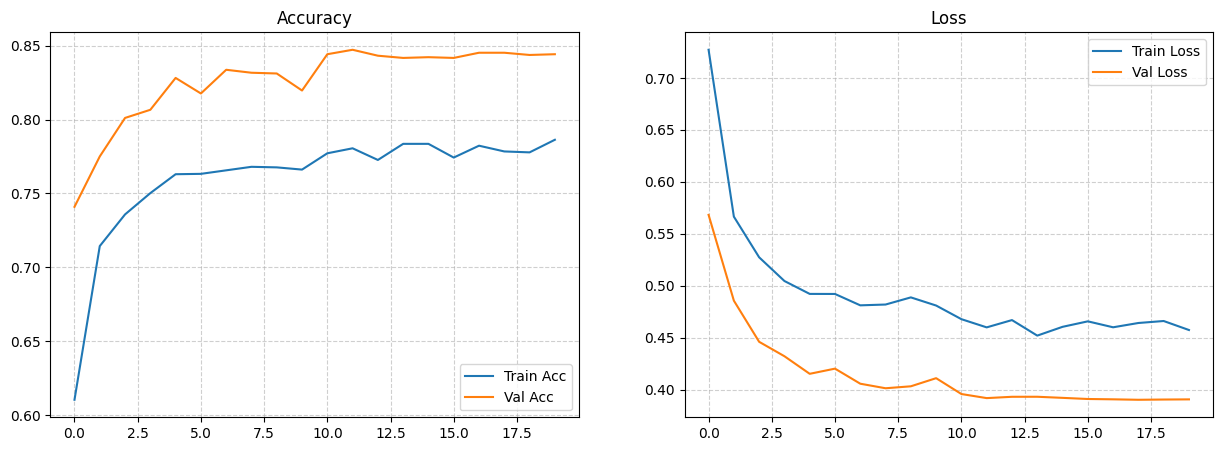

Generating predictions...
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

--- Classification Report ---
              precision    recall  f1-score   support

        Real       0.84      0.86      0.85      1012
        Fake       0.85      0.83      0.84       984

    accuracy                           0.85      1996
   macro avg       0.85      0.84      0.85      1996
weighted avg       0.85      0.85      0.85      1996



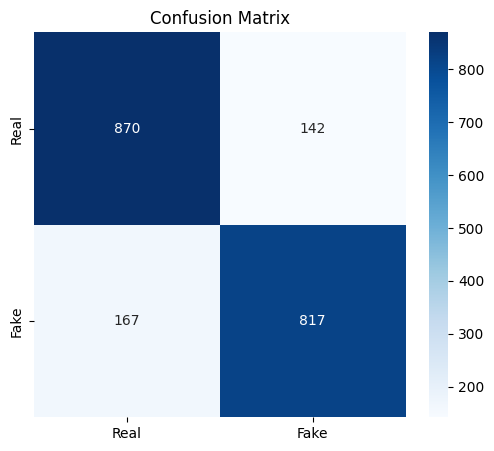

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Plot Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
ax1.plot(history.history['accuracy'], label='Train Acc')
ax1.plot(history.history['val_accuracy'], label='Val Acc')
ax1.set_title('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)


ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Loss')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
plt.show()

# 2. Generate Predictions
print("Generating predictions...")
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_pred_probs = model.predict(val_ds)
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Print Metrics
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

# 4. Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], yticklabels=['Real', 'Fake'])
plt.title('Confusion Matrix')
plt.show()

In [14]:
import cv2
import numpy as np
import tensorflow as tf
from mtcnn import MTCNN
import os
from IPython.display import display, HTML

# 1. Initialize detector and load your existing model
print("Loading model and face detector...")
MODEL_PATH = '/kaggle/working/best_model.h5'
model = tf.keras.models.load_model(MODEL_PATH)
detector = MTCNN()

def kaggle_predict_video(video_path, num_frames=15):
    """
    Runs deepfake detection on a video and displays a clean visual report 
    directly within the Kaggle Notebook output.
    """
    if not os.path.exists(video_path):
        print(f"Error: Video file not found at {video_path}")
        return
        
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    
    if total_frames == 0:
        print("Error: Could not read video frames.")
        return
        
    # Sample anchor frames evenly across the video
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    face_scores = []
    
    print(f"Analyzing {num_frames} frames from video...")
    
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
            
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        try:
            results = detector.detect_faces(frame_rgb)
        except Exception:
            results = []
            
        if results:
            x, y, w, h = results[0]['box']
            # Apply 15% padding safety margin
            x1, y1 = max(0, x - int(w*0.15)), max(0, y - int(h*0.15))
            x2, y2 = min(width, x + w + int(w*0.15)), min(height, y + h + int(h*0.15))
            
            face_crop = frame[y1:y2, x1:x2]
            if face_crop.size > 0:
                # Resize to EfficientNetB0 standard input size (224, 224)
                face_crop = cv2.resize(face_crop, (224, 224))
                img_array = tf.keras.preprocessing.image.img_to_array(face_crop)
                img_array = np.expand_dims(img_array, axis=0)
                preprocessed = tf.keras.applications.efficientnet.preprocess_input(img_array)
                
                # Predict
                prob = model.predict(preprocessed, verbose=0)[0][0]
                face_scores.append(prob)
                
    cap.release()
    
    # 2. Process Final Metrics
    if len(face_scores) == 0:
        print("⚠️ No clear faces detected in the sampled frames.")
        global_score = 0.5
    else:
        global_score = np.mean(face_scores)
        
    if global_score >= 0.5:
        verdict = "FAKE"
        confidence = global_score * 100
        theme_color = "#dc3545" # Crimson Red
        badge_bg = "#f8d7da"
    else:
        verdict = "REAL"
        confidence = (1 - global_score) * 100
        theme_color = "#28a745" # Forest Green
        badge_bg = "#d4edda"
        
    # 3. Render HTML Display Dashboard Card
    html_report = f"""
    <div style="border: 2px solid {theme_color}; border-radius: 8px; padding: 20px; max-width: 500px; background-color: #f8f9fa; font-family: Arial, sans-serif; margin-bottom: 20px;">
        <h3 style="margin-top: 0; color: #333;">Deepfake Detection System Report</h3>
        <hr style="border: 0; border-top: 1px solid #ccc; margin: 10px 0;">
        <p style="font-size: 16px; margin: 8px 0;"><strong>Source File:</strong> <code style="background-color: #e9ecef; padding: 2px 4px; border-radius: 4px;">{os.path.basename(video_path)}</code></p>
        <p style="font-size: 18px; margin: 8px 0;">
            <strong>Verdict:</strong> 
            <span style="color: {theme_color}; background-color: {badge_bg}; padding: 4px 12px; border-radius: 20px; font-weight: bold; border: 1px solid {theme_color};">
                {verdict}
            </span>
        </p>
        <p style="font-size: 16px; margin: 8px 0;"><strong>Confidence Score:</strong> <span style="font-size: 18px; font-weight: bold; color: {theme_color};">{confidence:.2f}%</span></p>
        <div style="background-color: #ddd; border-radius: 10px; height: 12px; width: 100%; margin-top: 15px; overflow: hidden;">
            <div style="background-color: {theme_color}; width: {confidence}%; height: 100%; transition: width 0.5s ease-in-out;"></div>
        </div>
        <p style="font-size: 12px; color: #6c757d; margin-top: 10px; margin-bottom: 0;">Raw Sigmoid Value: {global_score:.4f} (Threshold: 0.50)</p>
    </div>
    """
    display(HTML(html_report))

# --- HOW TO RUN ---
# Put any valid video path here from your dataset input
test_video = '/kaggle/input/datasets/xdxd003/ff-c23/FaceForensics++_C23/original/011.mp4'
kaggle_predict_video(test_video)

Loading model and face detector...


Analyzing 15 frames from video...


In [ ]:
can you make a new report by editing this report file i attached keep the format same as the given report file and keep the old fake news detection system with traditional ml models and add the new fakenews detection system with roberta, replace the old deepfake image detection system report with the new deepfake image detection one whose code i just provided you, also replace the old deepfake image detection system report with the new deepfake video detection whose code i just provided you, make all the necessery changes and give me the latex code for the whole new report 